In [1]:
# ==================
# Imports and Setup
# ==================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ---------------
# Load the Data
# ---------------

df = pd.read_csv("essay_features_engineered.csv")

print(df.shape)
df.head()

(24728, 8)


,score,word_count,sentence_count,avg_sentence_length,vocab_richness,readability,topic,semantic_cluster
0,4,396,17,23.294118,0.573232,12.096309,8,2
1,2,200,10,20.000000,0.605000,6.701153,8,2
2,3,371,31,11.967742,0.571429,6.538875,8,2
3,2,224,10,22.400000,0.598214,10.755697,8,2
4,2,219,7,31.285714,0.616438,14.089656,8,2


In [3]:
# ==================
# Inspect Features
# ==================
df.describe()
df.isna().sum()
df = df.dropna()

In [6]:
# ===============
# Define Targets
# ===============

# Essay Scores
X = df.drop(columns=["score"])
y = df["score"]

# Check Features
print(X.columns)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Index(['word_count', 'sentence_count', 'avg_sentence_length', 'vocab_richness',
       'readability', 'topic', 'semantic_cluster'],
      dtype='object')


In [8]:
# ------------------
# Feature Scaling
# ------------------

# Scaled for Linear Modeling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
# ---------------------------
# Linear Regression Baseline
# ---------------------------
lin_model = LinearRegression()

lin_model.fit(X_train_scaled, y_train)

lin_preds = lin_model.predict(X_test_scaled)

# Evaluate
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_preds))
lin_r2 = r2_score(y_test, lin_preds)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression R²:", lin_r2)

Linear Regression RMSE: 0.724471065141261
Linear Regression R²: 0.5072628009818182


In [11]:
# ------------------
# Random Forest
# ------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 0.6740125118410714
Random Forest R²: 0.5735096805127515


In [12]:
# -------------------
# Gradient Boosting
# -------------------

# Why do I let LLMs keep talking me into using these models, even though they never work for me?
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

# Evaluate
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting RMSE: 0.6622632977752282
Gradient Boosting R²: 0.5882490254992946


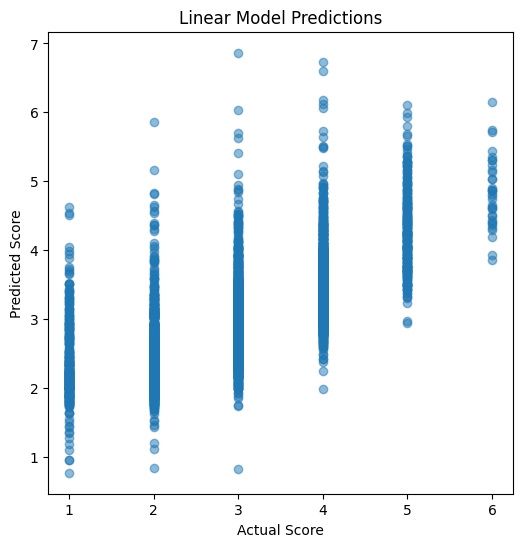

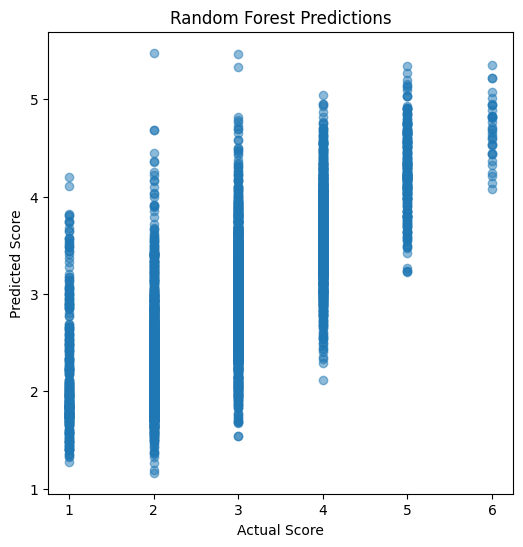

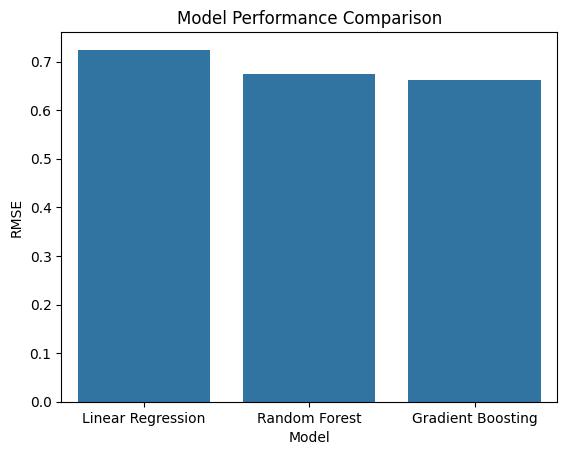

In [13]:
# ===================
# Visualizations
# ===================

# Predicted vs. Actual
# Linear Regression
plt.figure(figsize=(6,6))

plt.scatter(y_test, lin_preds, alpha=0.5)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Linear Model Predictions")

plt.show()

# Random Forest
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_preds, alpha=0.5)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Random Forest Predictions")

plt.show()

# Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lin_rmse, rf_rmse, gb_rmse],
    "R2": [lin_r2, rf_r2, gb_r2]
})

results

sns.barplot(x="Model", y="RMSE", data=results)

plt.title("Model Performance Comparison")

plt.show()

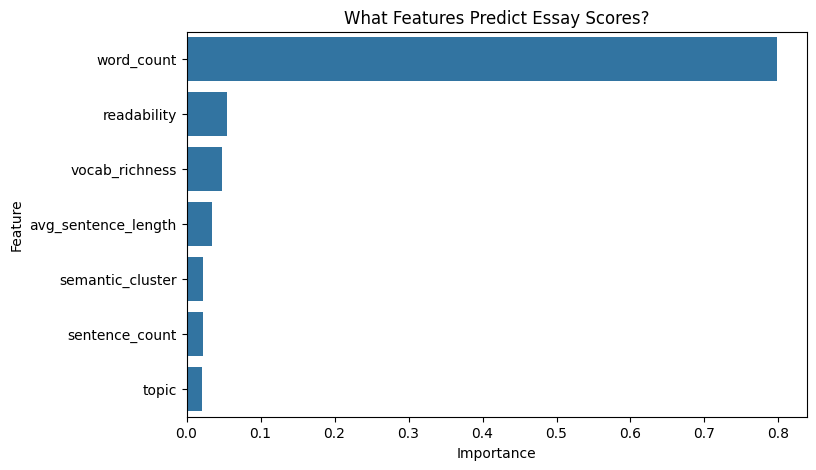

In [15]:
# ----------------------
# RF Feature Importance
# ----------------------

importances = rf_model.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_importance
)

plt.title("What Features Predict Essay Scores?")

plt.show()

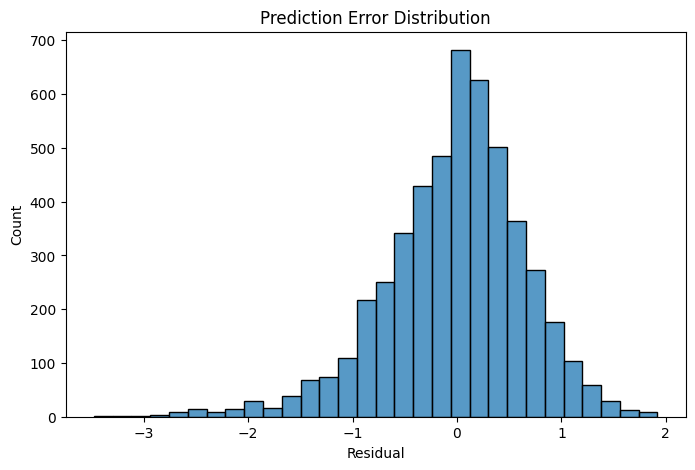

In [16]:
# ------------------
# Residual Analysis
# ------------------

# residuals
residuals = y_test - rf_preds

# Distribution Plot
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30)

plt.title("Prediction Error Distribution")

plt.xlabel("Residual")

plt.show()

In [17]:
# ------------------
# Save Predictions
# ------------------

pred_df = X_test.copy()

pred_df["actual_score"] = y_test
pred_df["predicted_score"] = rf_preds

pred_df.to_csv("essay_predictions.csv", index=False)